In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(101)

#synthetic dta for Price vs Demand
num_products = 200
price = np.random.rand(num_products) * 50 + 10

#non-linear relationship for demand
demand = 1000 - 15 * price + 0.3 * (price - 30)**2 + np.random.randn(num_products) * 50

tree_data = pd.DataFrame({'Price': price, 'Demand': demand})

display(tree_data.head())

,Price,Demand
0,35.819931,402.948026
1,38.533379,432.879343
2,11.423711,929.884056
3,18.576083,761.131573
4,44.263849,401.760880


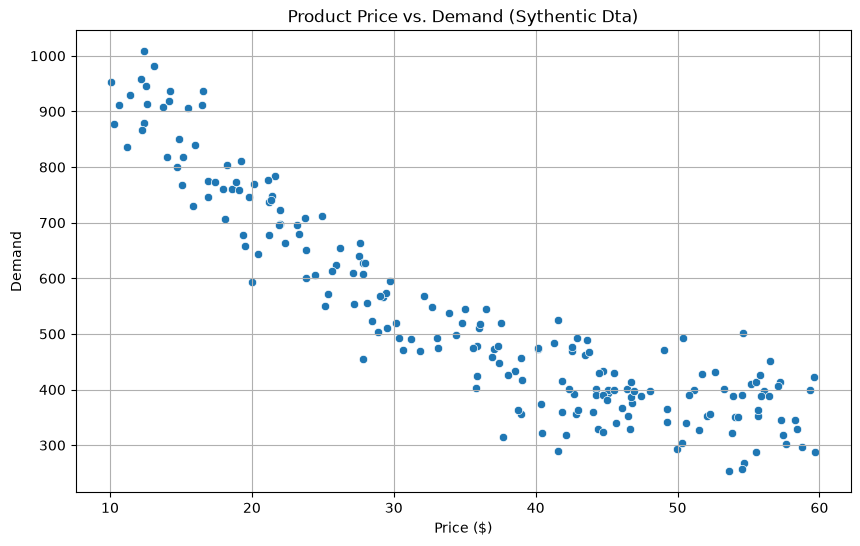

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Price', y='Demand', data=tree_data)
plt.title('Product Price vs. Demand (Sythentic Dta)')
plt.xlabel('Price ($)')
plt.ylabel('Demand')
plt.grid(True)
plt.show()

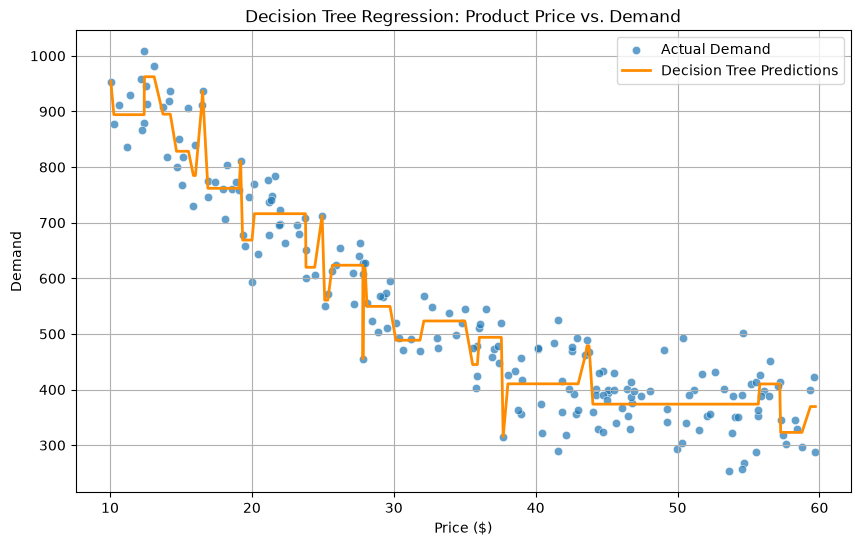

In [7]:
X_tree = tree_data[['Price']]
y_tree = tree_data['Demand']

tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_tree, y_tree)

y_tree_pred = tree_model.predict(X_tree)

# sort the data for dt pred line
sort_idx = X_tree.squeeze().argsort()
X_tree_sorted = X_tree.iloc[sort_idx]
y_tree_pred_sorted = y_tree_pred[sort_idx]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Price', y='Demand', data=tree_data, label='Actual Demand', alpha=0.7)
plt.plot(X_tree_sorted, y_tree_pred_sorted, color='darkorange', linewidth=2, label='Decision Tree Predictions')
plt.title('Decision Tree Regression: Product Price vs. Demand')
plt.xlabel('Price ($)')
plt.ylabel('Demand')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
r_squared_tree = r2_score(y_tree, y_tree_pred)
print(f"R-squared (Decision Tree): {r_squared_tree:.2f}")

mse_tree = mean_squared_error(y_tree, y_tree_pred)
print(f"Mean Squared Error (Decision Tree): {mse_tree:.2f}")

R-squared (Decision Tree): 0.95
Mean Squared Error (Decision Tree): 1863.17
